In [2]:
import numpy as np
import matplotlib.pyplot as plt
plt.style.use('fivethirtyeight')
import pandas as pd
from keras.callbacks import EarlyStopping
from sklearn.preprocessing import MinMaxScaler
from keras.models import Sequential
from keras.layers import Dense, LSTM, Dropout, GRU, Bidirectional, Input
from keras.optimizers import SGD, Adam
import math
from sklearn.metrics import mean_squared_error, mean_absolute_error, mean_absolute_percentage_error
from keras.losses import Huber

In [3]:
def plot_predictions(test,predicted):
  plt.plot(test, color='red',label='Real IBM Stock Price')
  plt.plot(predicted, color='blue',label='Predicted IBM Stock Price')
  plt.title('IBM Stock Price Prediction')
  plt.xlabel('Time')
  plt.ylabel('IBM Stock Price')
  plt.legend()
  plt.show()

def return_rmse(test, predicted):
  rmse = math.sqrt(mean_squared_error(test, predicted))
  print("-" * 30)
  print("Błąd redniokwadratowy modelu {:.2f}.".format(rmse))
  print("-" * 30)

def return_mae(test, predicted):
  mae = mean_absolute_error(test, predicted)
  mape = mean_absolute_percentage_error(test, predicted) * 100
  print("Średni błąd bezwzględny: {:.2f}.".format(mae))
  print("Średni błąd bezwzględny procentowy: {:.2f}%".format(mape))
  print("-" * 30)

In [5]:
dataset = pd.read_csv('IBM_2006-01-01_to_2018-01-01.csv', index_col='Date', parse_dates=['Date'])
dataset.head()

,Open,High,Low,Close,Volume,Name
Date,,,,,,
2006-01-03,82.45,82.55,80.81,82.06,11715200,IBM
2006-01-04,82.20,82.50,81.33,81.95,9840600,IBM
2006-01-05,81.40,82.90,81.00,82.50,7213500,IBM
2006-01-06,83.95,85.03,83.41,84.95,8197400,IBM
2006-01-09,84.10,84.25,83.38,83.73,6858200,IBM


In [6]:
training_set = dataset[:'2016'].iloc[:,1:2].values
test_set = dataset['2017':].iloc[:,1:2].values

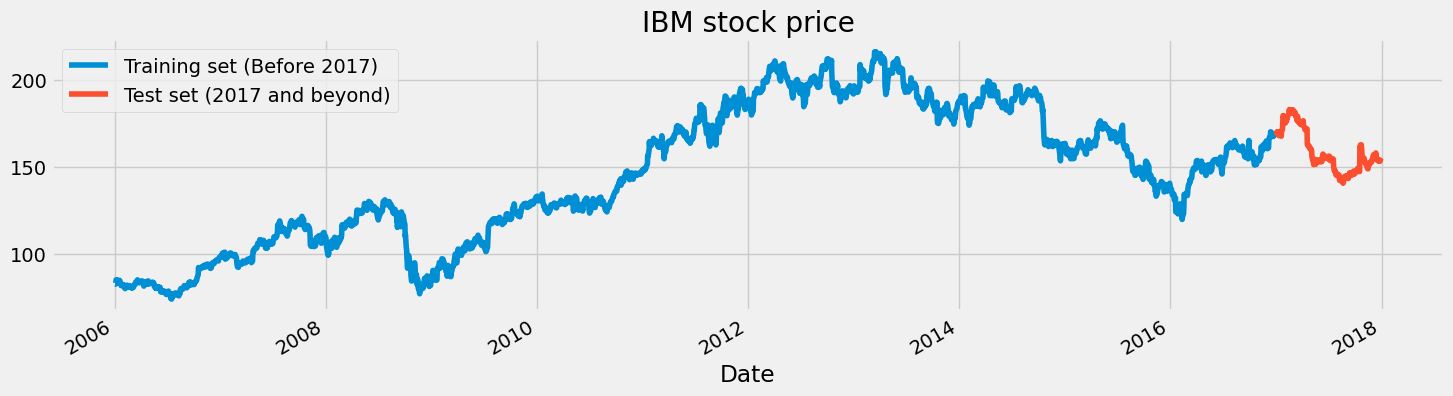

In [7]:
dataset["High"][:'2016'].plot(figsize=(16,4),legend=True)
dataset["High"]['2017':].plot(figsize=(16,4),legend=True)
plt.legend(['Training set (Before 2017)','Test set (2017 and beyond)'])
plt.title('IBM stock price')
plt.show()

In [8]:
sc = MinMaxScaler(feature_range=(0,1))
training_set_scaled = sc.fit_transform(training_set)

In [9]:
X_train = []
y_train = []
for i in range(60,2769):
  X_train.append(training_set_scaled[i-60:i,0])
  y_train.append(training_set_scaled[i,0])
X_train, y_train = np.array(X_train), np.array(y_train)

In [10]:
X_train = np.reshape(X_train, (X_train.shape[0],X_train.shape[1],1))

In [11]:
regressor = Sequential()
regressor.add(Input(shape=(X_train.shape[1], 1)))
regressor.add(LSTM(units=50, return_sequences=True))
regressor.add(Dropout(0.2))
regressor.add(LSTM(units=50, return_sequences=True))
regressor.add(Dropout(0.2))
regressor.add(LSTM(units=50, return_sequences=True))
regressor.add(Dropout(0.2))
regressor.add(LSTM(units=50))
regressor.add(Dropout(0.2))
regressor.add(Dense(units=1))

regressor.compile(optimizer='rmsprop',loss='mean_squared_error')

regressor.fit(X_train,y_train,epochs=50,batch_size=32)

Epoch 1/50
85/85 ━━━━━━━━━━━━━━━━━━━━ 10s 75ms/step - loss: 0.0187
Epoch 2/50
85/85 ━━━━━━━━━━━━━━━━━━━━ 6s 68ms/step - loss: 0.0098
Epoch 3/50
85/85 ━━━━━━━━━━━━━━━━━━━━ 6s 76ms/step - loss: 0.0084
Epoch 4/50
85/85 ━━━━━━━━━━━━━━━━━━━━ 6s 68ms/step - loss: 0.0066
Epoch 5/50
85/85 ━━━━━━━━━━━━━━━━━━━━ 6s 75ms/step - loss: 0.0062
Epoch 6/50
85/85 ━━━━━━━━━━━━━━━━━━━━ 6s 65ms/step - loss: 0.0055
Epoch 7/50
85/85 ━━━━━━━━━━━━━━━━━━━━ 7s 87ms/step - loss: 0.0051
Epoch 8/50
85/85 ━━━━━━━━━━━━━━━━━━━━ 6s 65ms/step - loss: 0.0048
Epoch 9/50
85/85 ━━━━━━━━━━━━━━━━━━━━ 6s 73ms/step - loss: 0.0044
Epoch 10/50
85/85 ━━━━━━━━━━━━━━━━━━━━ 5s 64ms/step - loss: 0.0045
Epoch 11/50
85/85 ━━━━━━━━━━━━━━━━━━━━ 6s 72ms/step - loss: 0.0037
Epoch 12/50
85/85 ━━━━━━━━━━━━━━━━━━━━ 6s 67ms/step - loss: 0.0035
Epoch 13/50
85/85 ━━━━━━━━━━━━━━━━━━━━ 6s 73ms/step - loss: 0.0035
Epoch 14/50
85/85 ━━━━━━━━━━━━━━━━━━━━ 10s 74ms/step - loss: 0.0035
Epoch 15/50
85/85 ━━━━━━━━━━━━━━━━━━━━ 6s 66ms/step - loss: 0.0031
Ep

In [12]:
dataset_total = pd.concat((dataset["High"][:'2016'],dataset["High"]['2017':]),axis=0)
inputs = dataset_total[len(dataset_total)-len(test_set) - 60:].values
inputs = inputs.reshape(-1,1)
inputs = sc.transform(inputs)

In [13]:
X_test = []
for i in range(60,311):
  X_test.append(inputs[i-60:i,0])
X_test = np.array(X_test)
X_test = np.reshape(X_test, (X_test.shape[0],X_test.shape[1],1))
predicted_stock_price = regressor.predict(X_test)
preedicted_stock_price = sc.inverse_transform(predicted_stock_price)

8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 124ms/step


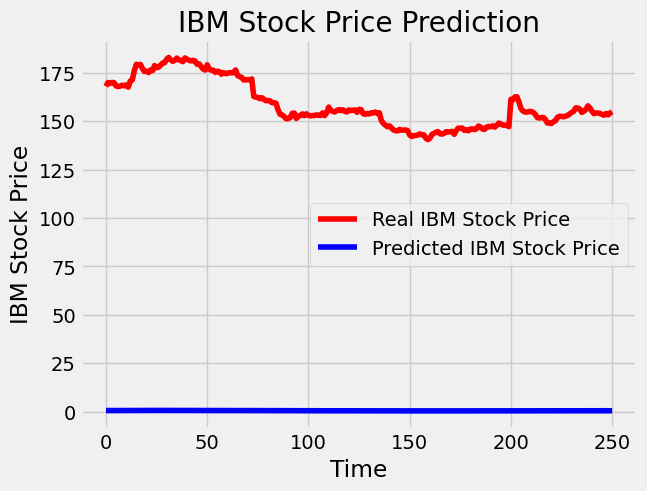

In [14]:
plot_predictions(test_set,predicted_stock_price)

In [15]:
return_rmse(test_set,predicted_stock_price)
return_mae(test_set,predicted_stock_price)

------------------------------
Błąd redniokwadratowy modelu 158.36.
------------------------------
Średni błąd bezwzględny: 157.90.
Średni błąd bezwzględny procentowy: 99.61%
------------------------------


In [16]:
regressorGRU = Sequential()
regressorGRU.add(Input(shape=(X_train.shape[1], 1)))
regressorGRU.add(GRU(units=50, return_sequences=True, activation='tanh'))
regressorGRU.add(Dropout(0.2))
regressorGRU.add(GRU(units=50, return_sequences=True, activation='tanh'))
regressorGRU.add(Dropout(0.2))
regressorGRU.add(GRU(units=50, return_sequences=True, activation='tanh'))
regressorGRU.add(Dropout(0.2))
regressorGRU.add(GRU(units=50, activation='tanh'))
regressorGRU.add(Dropout(0.2))
regressorGRU.add(Dense(units=1))

regressorGRU.compile(optimizer='rmsprop', loss='mean_squared_error')

early_stop = EarlyStopping(monitor='loss', patience=5, restore_best_weights=True)
regressorGRU.fit(X_train, y_train, epochs=100, batch_size=32, callbacks=[early_stop])

Epoch 1/100
85/85 ━━━━━━━━━━━━━━━━━━━━ 12s 85ms/step - loss: 0.0170
Epoch 2/100
85/85 ━━━━━━━━━━━━━━━━━━━━ 8s 90ms/step - loss: 0.0087
Epoch 3/100
85/85 ━━━━━━━━━━━━━━━━━━━━ 8s 90ms/step - loss: 0.0067
Epoch 4/100
85/85 ━━━━━━━━━━━━━━━━━━━━ 8s 90ms/step - loss: 0.0063
Epoch 5/100
85/85 ━━━━━━━━━━━━━━━━━━━━ 8s 94ms/step - loss: 0.0055
Epoch 6/100
85/85 ━━━━━━━━━━━━━━━━━━━━ 8s 91ms/step - loss: 0.0046
Epoch 7/100
85/85 ━━━━━━━━━━━━━━━━━━━━ 8s 93ms/step - loss: 0.0046
Epoch 8/100
85/85 ━━━━━━━━━━━━━━━━━━━━ 8s 97ms/step - loss: 0.0039
Epoch 9/100
85/85 ━━━━━━━━━━━━━━━━━━━━ 10s 95ms/step - loss: 0.0038
Epoch 10/100
85/85 ━━━━━━━━━━━━━━━━━━━━ 7s 87ms/step - loss: 0.0038
Epoch 11/100
85/85 ━━━━━━━━━━━━━━━━━━━━ 8s 96ms/step - loss: 0.0035
Epoch 12/100
85/85 ━━━━━━━━━━━━━━━━━━━━ 8s 96ms/step - loss: 0.0033
Epoch 13/100
85/85 ━━━━━━━━━━━━━━━━━━━━ 8s 88ms/step - loss: 0.0035
Epoch 14/100
85/85 ━━━━━━━━━━━━━━━━━━━━ 10s 86ms/step - loss: 0.0031
Epoch 15/100
85/85 ━━━━━━━━━━━━━━━━━━━━ 8s 94ms/step -

In [17]:
X_test = []
for i in range(60,311):
  X_test.append(inputs[i-60:i,0])
X_test = np.array(X_test)
X_test = np.reshape(X_test, (X_test.shape[0],X_test.shape[1],1))
GRU_predicted_stock_price = regressorGRU.predict(X_test)
GRU_predicted_stock_price = sc.inverse_transform(GRU_predicted_stock_price)

8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 79ms/step


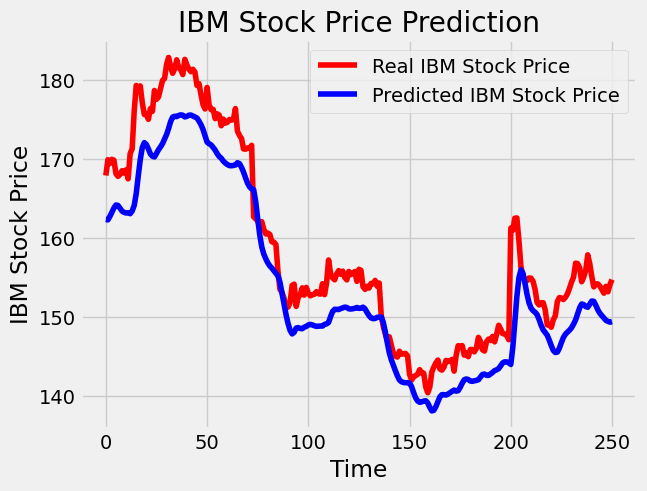

In [18]:
plot_predictions(test_set,GRU_predicted_stock_price)

In [19]:
return_rmse(test_set,GRU_predicted_stock_price)
return_mae(test_set,GRU_predicted_stock_price)

------------------------------
Błąd redniokwadratowy modelu 4.98.
------------------------------
Średni błąd bezwzględny: 4.43.
Średni błąd bezwzględny procentowy: 2.76%
------------------------------
